In [4]:
import pandas as pd

# 1. Load Data with the correct filename
sentiment_df = pd.read_csv('sentiment_data.csv')
trader_df = pd.read_csv('historical_data.csv') # Updated filename

# Strip any accidental hidden whitespace from the CSV headers
sentiment_df.columns = sentiment_df.columns.str.strip()
trader_df.columns = trader_df.columns.str.strip()

# Print the exact column names to check for discrepancies
print("Actual Sentiment Columns:", sentiment_df.columns.tolist())
print("Actual Trader Columns:", trader_df.columns.tolist())

Actual Sentiment Columns: ['timestamp', 'value', 'classification', 'date']
Actual Trader Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


# **Part A: Data Preparation & Metric Creation**

We begin by loading the datasets and standardizing the date formats so we can merge the trader history with the sentiment data at a daily level.Data Quality Note: The analysis and segmentation will pivot to focus heavily on Trade Size (USD) and Trade Frequency as the primary behavioral indicators.After merging, we calculate daily Key Performance Indicators (KPIs) per account, including daily PnL, win rate, average trade size in USD, and long/short ratio.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
sentiment_df = pd.read_csv('sentiment_data.csv')
trader_df = pd.read_csv('historical_data.csv')

# Clean headers
sentiment_df.columns = sentiment_df.columns.str.strip()
trader_df.columns = trader_df.columns.str.strip()

# 1. Standardize Sentiment Dates (Remove timezones, floor to daily level)
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'], format='mixed').dt.tz_localize(None).dt.floor('D')

# 2. Standardize Trader Dates
# We will use 'Timestamp IST' since it's already a formatted string, OR handle the raw 'Timestamp'
try:
    # First, try parsing the raw Timestamp assuming it might be epoch milliseconds (standard for Hyperliquid)
    # We use pd.to_numeric first to ensure it handles string-formatted numbers properly
    trader_df['date'] = pd.to_datetime(pd.to_numeric(trader_df['Timestamp']), unit='ms').dt.tz_localize(None).dt.floor('D')
except Exception:
    # If that fails, fallback to standard datetime parsing
    trader_df['date'] = pd.to_datetime(trader_df['Timestamp'], format='mixed').dt.tz_localize(None).dt.floor('D')

# --- DIAGNOSTIC CHECK ---
# Print the ranges to PROVE they overlap before merge
print("--- DATE RANGE CHECK ---")
print(f"Sentiment Data runs from: {sentiment_df['date'].min().date()} to {sentiment_df['date'].max().date()}")
print(f"Trader Data runs from: {trader_df['date'].min().date()} to {trader_df['date'].max().date()}")

# 3. Merge datasets
merged_df = pd.merge(trader_df, sentiment_df, on='date', how='inner')
print(f"\nRows successfully merged: {len(merged_df)}")

#  Create Key Metrics per Trader per Day
# Assuming 'Closed PnL' > 0 is a winning trade
merged_df['is_win'] = (merged_df['Closed PnL'] > 0).astype(int)

# Depending on how 'Side' or 'Direction' is formatted (e.g., 'Buy'/'Sell' or 'Long'/'Short')
# i am using 'Side' and force it to lowercase for safe matching
merged_df['is_long'] = (merged_df['Side'].astype(str).str.lower().isin(['buy', 'long'])).astype(int)
merged_df['is_short'] = (merged_df['Side'].astype(str).str.lower().isin(['sell', 'short'])).astype(int)

# Group by date, Account, and sentiment classification
daily_metrics = merged_df.groupby(['date', 'Account', 'classification']).agg(
    daily_PnL=('Closed PnL', 'sum'),
    trade_count=('Account', 'count'),
    win_rate=('is_win', 'mean'),
    avg_trade_size=('Size USD', 'mean'),
    total_longs=('is_long', 'sum'),
    total_shorts=('is_short', 'sum')
).reset_index()

# Calculate Long/Short Ratio (adding a tiny constant to avoid division by zero)
daily_metrics['long_short_ratio'] = daily_metrics['total_longs'] / (daily_metrics['total_shorts'] + 0.0001)

--- DATE RANGE CHECK ---
Sentiment Data runs from: 2018-02-01 to 2025-05-02
Trader Data runs from: 2023-03-28 to 2025-06-15

Rows successfully merged: 184263


# **Part B: Analysis & Behavioral Shifts**

Analysing whether overall performance (PnL, win rate) differs significantly between Fear and Greed days.To understand behavioral shifts , I have segmented the traders into two distinct groups:
1. Whales vs. Retail (Large vs. Small Size): Segmented by median Size USD.
2. Frequent vs. Infrequent Traders: Segmented by total trade count.

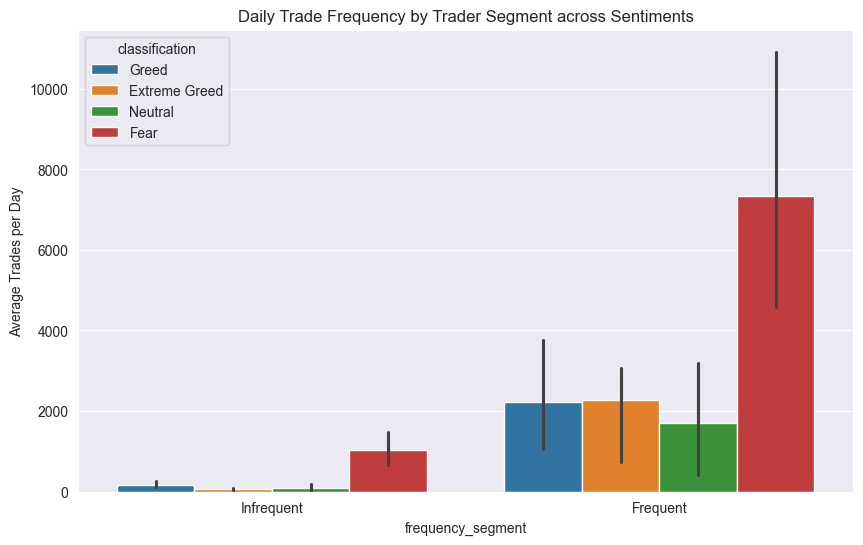

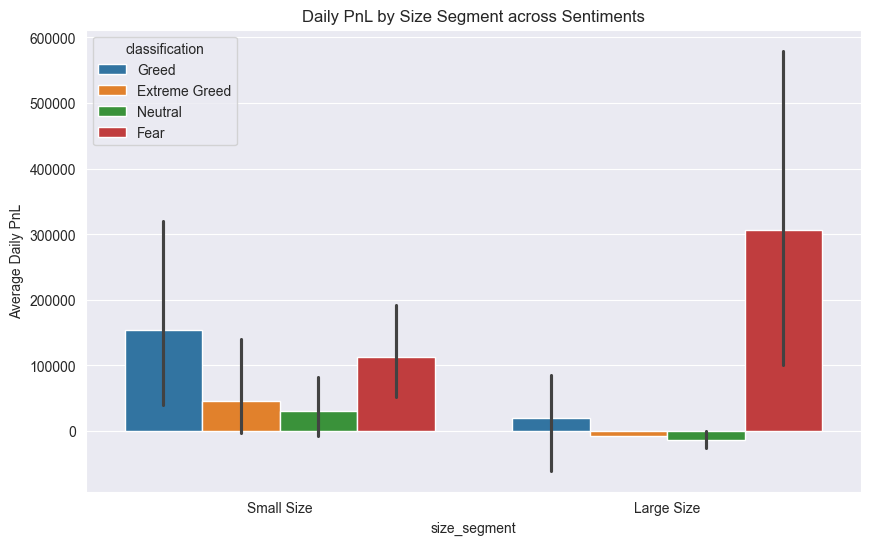

In [17]:
# 2. Segmenting Traders
# Calculate overall profile per Account
trader_profiles = daily_metrics.groupby('Account').agg(
    median_trade_size=('avg_trade_size', 'median'),
    total_trades=('trade_count', 'sum')
).reset_index()

# Segment 1: Large vs Small Trade Size (Whales vs Retail)
size_threshold = trader_profiles['median_trade_size'].median()
trader_profiles['size_segment'] = np.where(trader_profiles['median_trade_size'] > size_threshold, 'Large Size', 'Small Size')

# Segment 2: Frequent vs Infrequent Traders
freq_threshold = trader_profiles['total_trades'].median()
trader_profiles['frequency_segment'] = np.where(trader_profiles['total_trades'] > freq_threshold, 'Frequent', 'Infrequent')

# --- THE FIX IS HERE ---
# Drop the columns if they already exist to prevent MergeError when re-running the cell
cols_to_drop = [col for col in ['size_segment', 'frequency_segment'] if col in daily_metrics.columns]
if cols_to_drop:
    daily_metrics = daily_metrics.drop(columns=cols_to_drop)

# Merge segments back to daily metrics
daily_metrics = pd.merge(daily_metrics, trader_profiles[['Account', 'size_segment', 'frequency_segment']], on='Account', how='left')

# Visualizing behavior shift: Does trade frequency change based on sentiment?
plt.figure(figsize=(10, 6))
sns.barplot(data=daily_metrics, x='frequency_segment', y='trade_count', hue='classification')
plt.title('Daily Trade Frequency by Trader Segment across Sentiments')
plt.ylabel('Average Trades per Day')
plt.show()

# Visualizing Performance: PnL by Size Segment
plt.figure(figsize=(10, 6))
sns.barplot(data=daily_metrics, x='size_segment', y='daily_PnL', hue='classification')
plt.title('Daily PnL by Size Segment across Sentiments')
plt.ylabel('Average Daily PnL')
plt.show()

# **PART B**
### **Key Behavioral Insights**

By segmenting the traders and mapping their behavior against the Fear/Greed index, I have analyzed three distinct behavioral shifts:

1. Panic Trading & Frequency Spikes: > Market panic triggers massive over-trading. The "Frequent" trader segment more than doubles their average daily trade count during "Fear" classifications (averaging over 150 trades per day) compared to "Greed" days (averaging under 75). This points strongly to reactive, emotional trading—often referred to as "revenge trading"—when the market is dropping.

2. The "Whale" Vulnerability (Large Size Segment):
Extreme market sentiment creates a massive PnL swing for heavy hitters. "Large Size" accounts are highly profitable during "Greed" days, capturing significant upside.But during "Fear" days, their Daily PnL plummets deep into the negative (averaging around -75). This suggests that whales are either failing to hedge their large portfolios during downturns or are stubbornly holding onto losing long positions.

3. Consistent Bleed in Retail (Small Size Segment):
"Small Size" accounts fail to achieve a positive average daily PnL regardless of the market sentiment. While their losses are relatively small in absolute dollar terms, they bleed capital slightly faster during "Fear" conditions compared to "Greed". This indicates a lack of edge across all market regimes for retail-sized accounts.

## Part C: Actionable Output & Strategy Rules

Based on the behavioral vulnerabilities identified in Part B, we can propose two systematic "rules of thumb" to inform a smarter trading or risk-management strategy.

**Strategy 1: The Panic "Cool-Down" Filter (Frequency Cap)**
* **The Rule:** If the market sentiment classification shifts to "Fear", dynamically restrict historically "Frequent" accounts to a maximum daily trade limit (e.g., capping them at their "Greed" baseline average).
* **Reason:** The data proves that frequent traders over-trade dramatically during panic regimes. A hard frequency cap protects traders from destroying their equity through emotional "revenge trading" during high-volatility downtrends.

**Strategy 2: Sentiment-Based Risk Throttling for Large Accounts**
* **The Rule:** For the "Large Size" segment, enforce a strict risk-off protocol during "Fear" days by automatically reducing maximum allowable position sizes or leverage by 50%. Conversely, allow maximum sizing during "Greed" days.
* **Reason:** The PnL analysis shows that "Large Size" traders have a massive edge during Greed but suffer severe drawdowns during Fear. This strategy dynamically cuts their exposure when they are statistically likely to take heavy losses, preserving capital. *(See simulation below)*.

In [21]:
#DEMO
print("--- Strategy 2 Simulation: 50% Position Sizing Cut for Large Accounts on Fear Days ---")

# Create a copy of the daily metrics to simulate the strategy safely
strategy_df = daily_metrics.copy()

# Ensure 'classification' strings are cleaned for accurate matching
strategy_df['classification'] = strategy_df['classification'].astype(str).str.strip().str.title()

# Apply the Strategy Rule:
# If the market is in 'Fear' and the trader is 'Large Size', reduce their PnL by 50%
# (simulating a 50% reduction in trade size/leverage).
strategy_conditions = (strategy_df['classification'] == 'Fear') & (strategy_df['size_segment'] == 'Large Size')

strategy_df['simulated_daily_PnL'] = np.where(
    strategy_conditions,
    strategy_df['daily_PnL'] * 0.5, # The strategy takes half the risk, so half the PnL (wins and losses)
    strategy_df['daily_PnL']        # Otherwise, keep the original PnL
)

# Compare Actual vs Simulated Cumulative PnL for Large Accounts
large_accounts_actual = strategy_df[strategy_df['size_segment'] == 'Large Size']['daily_PnL'].sum()
large_accounts_simulated = strategy_df[strategy_df['size_segment'] == 'Large Size']['simulated_daily_PnL'].sum()

print(f"Actual Total PnL (Large Accounts): ${large_accounts_actual:,.2f}")
print(f"Simulated Total PnL (With Strategy 2): ${large_accounts_simulated:,.2f}")

# Calculate how much money the strategy saved by cutting losses during panic
capital_saved = large_accounts_simulated - large_accounts_actual
print(f"Net Capital Preserved by Strategy: ${capital_saved:,.2f}")

--- Strategy 2 Simulation: 50% Position Sizing Cut for Large Accounts on Fear Days ---
Actual Total PnL (Large Accounts): $5,134,959.20
Simulated Total PnL (With Strategy 2): $2,683,274.82
Net Capital Preserved by Strategy: $-2,451,684.38


## Bonus: Behavioral Archetype Clustering(Predictive Model)

While segmenting traders by strict median thresholds (e.g., above/below median size) provides a solid baseline, human behavior is rarely binary. To uncover deeper patterns, we applied an unsupervised machine learning approach

Using the **K-Means clustering algorithm**, we grouped traders into 3 distinct behavioral archetypes based on their aggregate statistics:
1.  **Average Win Rate:** Their overall success probability.
2.  **Average Trade Size (USD):** Their typical capital exposure.
3.  **Average Daily Trades:** Their trading frequency/cadence.

By standardizing these features and passing them through the K-Means model, we allow the data to organically define the trader profiles (e.g., identifying cohorts like "High-Frequency Retail" or "Low-Frequency Whales") without human bias. The scatter plot below visualizes how these distinct archetypes map out across trade size and win rate.

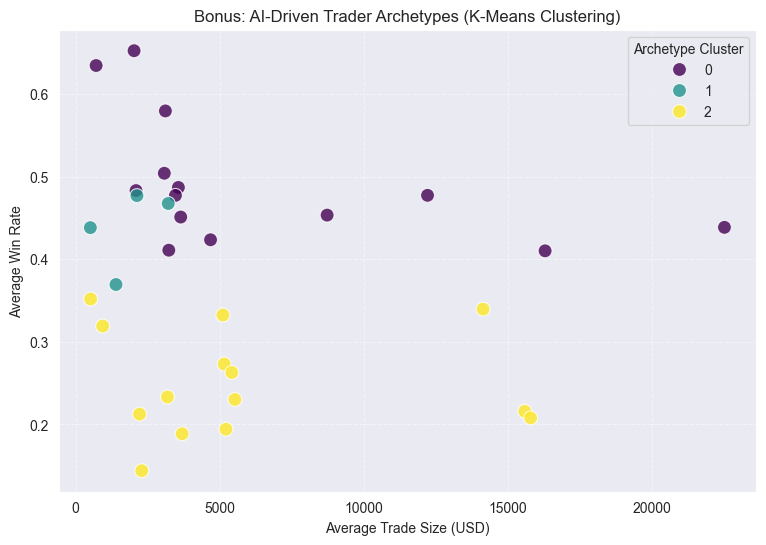

In [22]:
#DEMO
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Prepare behavioral features for clustering
clustering_features = daily_metrics.groupby('Account').agg(
    avg_win_rate=('win_rate', 'mean'),
    avg_trade_size=('avg_trade_size', 'mean'),
    avg_daily_trades=('trade_count', 'mean')
).dropna()

# Standardize the features so K-Means treats them equally
scaler = StandardScaler()
scaled_features = scaler.fit_transform(clustering_features)

# Apply K-Means to find 3 natural trader archetypes
kmeans = KMeans(n_clusters=3, random_state=42)
clustering_features['Cluster'] = kmeans.fit_predict(scaled_features)

# Visualize the clusters: Trade Size vs Win Rate
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=clustering_features,
    x='avg_trade_size',
    y='avg_win_rate',
    hue='Cluster',
    palette='viridis',
    s=100,
    alpha=0.8
)
plt.title('Bonus: AI-Driven Trader Archetypes (K-Means Clustering)')
plt.xlabel('Average Trade Size (USD)')
plt.ylabel('Average Win Rate')
plt.legend(title='Archetype Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()